In [ ]:
from google.colab import files
uploaded = files.upload()



Saving archive.zip to archive.zip


In [ ]:
import zipfile

zip_path = "archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Files extracted:", zip_ref.namelist())


Files extracted: ['emotions.csv']


In [ ]:
import pandas as pd

df = pd.read_csv("data/emotions.csv")
df.head()

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.070,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00,NEGATIVE
1,28.80,33.1,32.0,25.8,22.8,6.550,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57,NEUTRAL
2,8.90,29.4,-416.0,16.7,23.7,79.900,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00,POSITIVE
3,14.90,31.6,-143.0,19.8,24.3,-0.584,-0.284,8.82,2.30,-1.97,...,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40,POSITIVE
4,28.30,31.3,45.2,27.3,24.5,34.800,-5.790,3.06,41.40,5.52,...,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60,NEUTRAL


In [ ]:
# Replace labels
df['label'] = df['label'].replace({
    'Happy': 'Elevated Cognitive State',
    'Neutral': 'Neutral Cognitive State',
    'Sad': 'Reduced Cognitive State'
})

print(df['label'].value_counts())


label
Neutral Cognitive State     716
Reduced Cognitive State     708
Elevated Cognitive State    708
Name: count, dtype: int64


In [ ]:
df.to_csv("updated_dataset.csv", index=False)


In [ ]:
# Using map
label_mapping = {
    'Elevated Cognitive State': 2,
    'Neutral Cognitive State': 1,
    'Reduced Cognitive State': 0
}
df['label'] = df['label'].map(label_mapping)

print(df.head())


   # mean_0_a  mean_1_a  mean_2_a  mean_3_a  mean_4_a  mean_d_0_a  mean_d_1_a  \
0        4.62      30.3    -356.0      15.6      26.3       1.070       0.411   
1       28.80      33.1      32.0      25.8      22.8       6.550       1.680   
2        8.90      29.4    -416.0      16.7      23.7      79.900       3.360   
3       14.90      31.6    -143.0      19.8      24.3      -0.584      -0.284   
4       28.30      31.3      45.2      27.3      24.5      34.800      -5.790   

   mean_d_2_a  mean_d_3_a  mean_d_4_a  ...  fft_741_b  fft_742_b  fft_743_b  \
0      -15.70        2.06        3.15  ...       23.5       20.3       20.3   
1        2.88        3.83       -4.82  ...      -23.3      -21.8      -21.8   
2       90.20       89.90        2.03  ...      462.0     -233.0     -233.0   
3        8.82        2.30       -1.97  ...      299.0     -243.0     -243.0   
4        3.06       41.40        5.52  ...       12.0       38.1       38.1   

   fft_744_b  fft_745_b  fft_746_b  ff

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('label', axis=1)  # features
y = df['label']               # labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# Example shape: (num_samples, time_steps, num_channels)
# Build Bi-LSTM model in Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional

# Define time_steps and num_channels based on X_train shape
num_features = X_train.shape[1]
time_steps = 1  # Assuming each sample is a single time step
num_channels = num_features

# Reshape input data for LSTM
X_train = X_train.reshape(X_train.shape[0], time_steps, num_channels)
X_test = X_test.reshape(X_test.shape[0], time_steps, num_channels)

model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=False), input_shape=(time_steps, num_channels)))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.8418 - loss: 0.3963 - val_accuracy: 0.9438 - val_loss: 0.1706
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9407 - loss: 0.1499 - val_accuracy: 0.9532 - val_loss: 0.1433
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9536 - loss: 0.1218 - val_accuracy: 0.9649 - val_loss: 0.1402
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9742 - loss: 0.0811 - val_accuracy: 0.9602 - val_loss: 0.1131
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9761 - loss: 0.0739 - val_accuracy: 0.9672 - val_loss: 0.1009
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9841 - loss: 0.0513 - val_accuracy: 0.9625 - val_loss: 0.0978
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9865 - loss: 0.0474 - val_accuracy: 0.9649 - val_loss: 0.0885
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9942 - loss: 0.0280 - val_accuracy: 0.9719 - v

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred_probabilities = model.predict(X_test)
y_pred = np.argmax(y_pred_probabilities, axis=1)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       142
           1       0.99      1.00      1.00       143
           2       0.99      0.96      0.97       142

    accuracy                           0.98       427
   macro avg       0.98      0.98      0.98       427
weighted avg       0.98      0.98      0.98       427

[[140   0   2]
 [  0 143   0]
 [  5   1 136]]


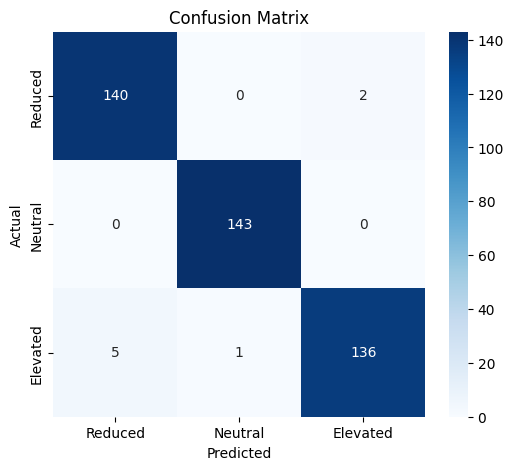

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Reduced', 'Neutral', 'Elevated'],
            yticklabels=['Reduced', 'Neutral', 'Elevated'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Reduced', 'Neutral', 'Elevated']))


              precision    recall  f1-score   support

     Reduced       0.97      0.99      0.98       142
     Neutral       0.99      1.00      1.00       143
    Elevated       0.99      0.96      0.97       142

    accuracy                           0.98       427
   macro avg       0.98      0.98      0.98       427
weighted avg       0.98      0.98      0.98       427



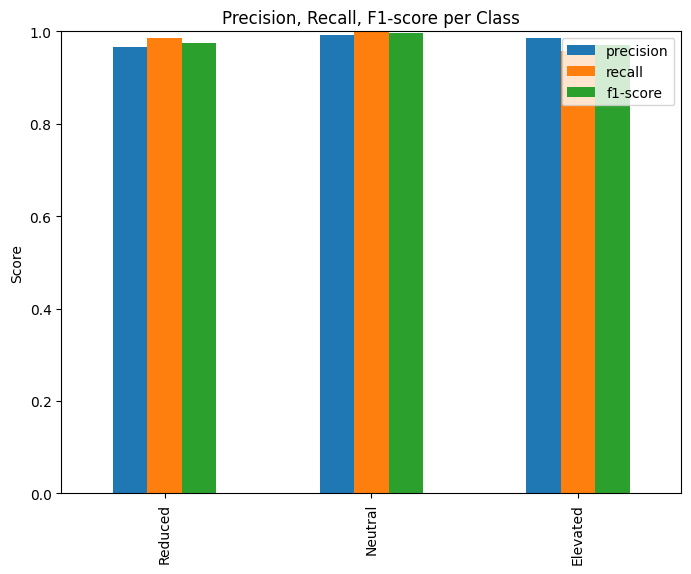

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# True and predicted labels
y_true = [0]*142 + [1]*143 + [2]*142   # example to match your counts
y_pred = [0]*140 + [2]*2 + [1]*143 + [2]*136 + [0]*5 + [1]*1

# Define the labels explicitly
labels = ['Reduced', 'Neutral', 'Elevated']

report = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Plot precision, recall, F1-score
metrics = ['precision', 'recall', 'f1-score']
df_report.iloc[:-3][metrics].plot(kind='bar', figsize=(8,6))
plt.title('Precision, Recall, F1-score per Class')
plt.ylabel('Score')
plt.ylim(0,1)
plt.show()